# Modelagem: baseline por regras × modelo de ML

O baseline por regras (`src/models/rules.py`) já acerta ~94% no extrato sintético. Então,
**por que treinar um modelo?** Este notebook responde isso de forma honesta — e a resposta
não é "o ML bate o baseline em accuracy".

Toda a lógica mora em `src/models/train.py`; aqui eu só **chamo** as funções e leio os
resultados, pra o notebook não divergir do código que vai pro app.

> Dados **sintéticos** — nenhum extrato real entra no projeto, por privacidade.

In [1]:
import sys
from pathlib import Path

# Acha a raiz do repo (onde está `src/`) subindo a partir do diretório de execução,
# pra os imports funcionarem rodando de notebooks/ ou da raiz.
raiz = Path.cwd()
while not (raiz / "src").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

import pandas as pd
import matplotlib.pyplot as plt

from src.models.train import avaliar_holdout, experimento_generalizacao, experimento_limite

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

df = pd.read_csv(raiz / "data/sample/extrato_exemplo.csv")
print(f"{len(df)} transações, {df['categoria'].nunique()} categorias")

600 transações, 9 categorias


## 1. In-distribution: o empate esperado

Split **estratificado** (as classes são desbalanceadas — um split aleatório puro poderia
deixar saúde/educação quase fora do teste). Comparo regras e ML **no mesmo conjunto de teste**,
com os lojistas escritos do jeito que o gerador já conhece.

In [2]:
h = avaliar_holdout(df)
print(f"regras: {h['acc_regras']:.3f}")
print(f"ML    : {h['acc_ml']:.3f}")

regras: 0.947
ML    : 0.927


**Leitura:** empate (ML às vezes até um pouco abaixo). E isso é **esperado**, não um
fracasso: o dado é **circular** — as descrições foram geradas a partir das mesmas keywords que
as regras consultam, então um classificador por keyword praticamente reconstrói o gerador.

Se eu parasse aqui, a conclusão honesta seria "regra barata resolve; ML não se justifica". O
valor do ML está em outro lugar — nas duas seções a seguir.

## 2. Generalização: variação de grafia (o ponto alto)

Extrato de verdade escreve o **mesmo** lojista de N formas (`IFOOD`, `IFD`, `IFOOOD`,
`BURGUER KING`). A regra por keyword exata **erra** a grafia que ninguém catalogou; o n-grama
de caractere a reconhece pela sobreposição parcial (`ifoood` compartilha `ifoo`/`food` com
`ifood`).

`experimento_generalizacao` treina o ML em toda a base e o avalia num conjunto de variantes
construídas pra **não** conter nenhuma keyword exata — isolando justamente esse caso.

In [3]:
g = experimento_generalizacao(df)
print(f"regras: {g['acc_regras']:.3f}")
print(f"ML    : {g['acc_ml']:.3f}")

regras: 0.000
ML    : 0.967


In [4]:
# Alguns exemplos: grafia crua -> o que cada abordagem previu (vs verdade).
amostra = g["df"].copy()
amostra["pred_regras"] = g["pred_regras"]
amostra["pred_ml"] = g["pred_ml"]
cols = ["descricao", "categoria", "pred_regras", "pred_ml"]
amostra.sample(8, random_state=1)[cols]

,descricao,categoria,pred_regras,pred_ml
228,TEF FARMCIA SP 862105,saude,outros,saude
194,estapr,transporte,outros,transporte
88,VIVU FIXO,contas_fixas,outros,contas_fixas
95,ASAI,mercado,outros,mercado
214,RAPPY 310995,alimentacao,outros,alimentacao
4,SHEL BOX,transporte,outros,transporte
93,ASAI,mercado,outros,mercado
27,VIVU FIBRA,contas_fixas,outros,contas_fixas


**Leitura:** aqui o ML ganha com folga. A regra cai em `outros` (não reconhece a grafia)
e despenca; o ML segura porque enxerga as subsequências de caractere. **É este o argumento do
projeto:** o ML não existe pra bater accuracy num benchmark circular, existe pra aguentar a
bagunça de grafia de um extrato real.

## 3. Limite honesto: marca 100% inédita

E se o lojista for uma marca **totalmente** nova (`OUTBACK`, `ZAFFARI`), sem nenhuma
sobreposição de caractere com o treino? Aí **não há sinal de texto pra ninguém** — nem regra,
nem n-grama. Vale mostrar onde o modelo **não** ajuda; esconder isso seria desonesto.

In [5]:
lim = experimento_limite(df)
n_classes_lojista = lim["df"]["categoria"].nunique()  # só categorias de lojista (sem transf./outros)
print(f"regras: {lim['acc_regras']:.3f}")
print(f"ML    : {lim['acc_ml']:.3f}  (acaso ≈ {1/n_classes_lojista:.3f} entre as {n_classes_lojista} categorias de lojista)")

regras: 0.000
ML    : 0.154  (acaso ≈ 0.143 entre as 7 categorias de lojista)


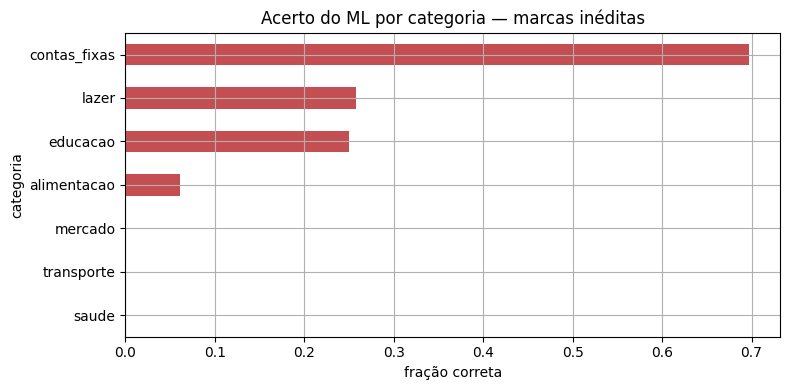

categoria
alimentacao     0.06
contas_fixas    0.70
educacao        0.25
lazer           0.26
mercado         0.00
saude           0.00
transporte      0.00
dtype: float64

In [6]:
# Por que o ML não fica em ZERO como as regras? Sobra um sinal: o VALOR.
novos = lim["df"].copy()
novos["pred_ml"] = lim["pred_ml"]
acerto_cat = (novos["categoria"] == novos["pred_ml"]).groupby(novos["categoria"]).mean()
ax = acerto_cat.sort_values().plot(kind="barh", color="#C44E52")
ax.set_title("Acerto do ML por categoria — marcas inéditas")
ax.set_xlabel("fração correta"); plt.tight_layout(); plt.show()
acerto_cat.round(2)

**Leitura:** o ML fica ~no nível do acaso, mas **não** em zero como as regras — ele
acerta `contas_fixas` (valores altos e característicos) e erra o resto. Ou seja: sem texto,
sobra só o **valor**, que separa categorias caras das baratas e nada mais.

Essa é a **fronteira** da abordagem e o gancho pro trabalho futuro: pra classificar marcas
genuinamente novas seria preciso outro sinal (base de lojistas, embeddings, enriquecimento
externo) — não mais n-grama.

## Resumo

Os três cenários lado a lado contam a história inteira.

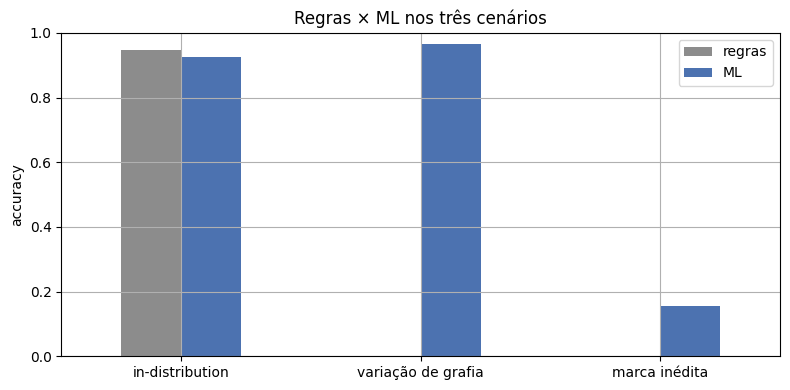

,regras,ML
in-distribution,0.947,0.927
variação de grafia,0.000,0.967
marca inédita,0.000,0.154


In [7]:
resumo = pd.DataFrame(
    {
        "regras": [h["acc_regras"], g["acc_regras"], lim["acc_regras"]],
        "ML": [h["acc_ml"], g["acc_ml"], lim["acc_ml"]],
    },
    index=["in-distribution", "variação de grafia", "marca inédita"],
)
ax = resumo.plot(kind="bar", color=["#8C8C8C", "#4C72B0"])
ax.set_title("Regras × ML nos três cenários")
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
plt.xticks(rotation=0); plt.legend(loc="upper right"); plt.tight_layout(); plt.show()
resumo.round(3)

**O retrato dos três cenários:**
- **In-distribution**, regra e ML empatam — num dado circular, a regra barata basta.
- **Em variação de grafia** (a realidade de um extrato), o ML supera as regras com folga: é
  onde ele se paga.
- **Em marca inédita**, ambos falham; o ML só não zera por causa do valor. É o limite
  declarado da abordagem.

Mas accuracy é uma lente grossa demais com classes desbalanceadas. As próximas seções abrem
o desempenho **por classe** e introduzem a **confiança por predição** — o segundo motivo de o
ML existir aqui.

## 4. Além da accuracy: precisão/recall por classe

Accuracy global **engana** com classes desbalanceadas: um modelo que só acertasse as
categorias frequentes já mostraria um número alto, escondendo que ignora as raras (saúde,
educação). E justamente nas raras o erro costuma custar mais — deixar de flaggar um gasto de
saúde (falso negativo) é pior que um falso positivo. Por isso olho **recall e f1 por classe**,
não a média.

Uso o mesmo holdout estratificado da seção 1.

In [8]:
from sklearn.metrics import classification_report

print(classification_report(h["y_true"], h["pred_ml"], zero_division=0))

               precision    recall  f1-score   support

  alimentacao       0.94      0.94      0.94        35
 contas_fixas       0.90      1.00      0.95        19
     educacao       0.89      1.00      0.94         8
        lazer       0.93      0.87      0.90        15
      mercado       0.94      0.81      0.87        21
       outros       0.80      1.00      0.89         4
        saude       0.80      0.67      0.73         6
transferencia       0.90      0.95      0.93        20
   transporte       1.00      1.00      1.00        22

     accuracy                           0.93       150
    macro avg       0.90      0.92      0.91       150
 weighted avg       0.93      0.93      0.93       150



**Leitura:** o `support` mostra o desbalanceamento (alimentação/mercado com dezenas de
exemplos, saúde/educação com poucos). O `class_weight="balanced"` é o que segura o recall das
raras — sem ele, o modelo as sacrificaria pra maximizar a accuracy global. Olhe o f1 das
classes raras: é a métrica que diz se o modelo é usável nelas, não a accuracy.

## 5. Matriz de confusão: *quais* categorias se confundem

Mais útil que "errou X%" é saber **com o quê** errou. A matriz revela se a confusão é
inofensiva (categorias próximas) ou preocupante.

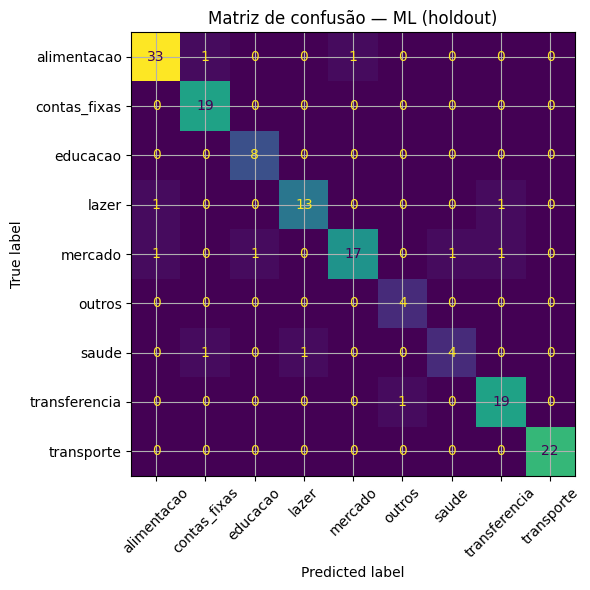

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    h["y_true"], h["pred_ml"], xticks_rotation=45, ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusão — ML (holdout)")
plt.tight_layout(); plt.show()

**Leitura:** a diagonal concentra os acertos. Fora dela, a confusão esperada é entre
**transferência ↔ outros** — ambiguidade que *injetei de propósito* no gerador (`PIX*` aparece
nas duas), e parte do label noise (3%) que nenhum modelo honesto zera. Não é o modelo "burro";
é o teto do dado. Confusões assim, entre categorias genéricas, são bem menos graves que
confundir, digamos, saúde com lazer.

## 6. AUC: separação independente do limiar

A AUC (one-vs-rest, média macro) mede o quão bem o modelo **ordena** as classes pela
probabilidade, sem fixar um limiar de decisão. Macro (não ponderada) pra dar às classes raras
o mesmo peso das frequentes — coerente com a decisão de não deixar as raras invisíveis.

In [10]:
from sklearn.metrics import roc_auc_score

proba_te = h["pipeline"].predict_proba(h["X_test"])
auc = roc_auc_score(
    h["y_true"], proba_te, multi_class="ovr", average="macro", labels=h["pipeline"].classes_,
)
print(f"ROC-AUC (OvR, macro): {auc:.3f}")

ROC-AUC (OvR, macro): 0.987


**Leitura:** AUC bem acima de 0,5 mostra que, mesmo quando erra a classe final, o modelo
quase sempre coloca a categoria certa entre as mais prováveis — o que dá base pra usar a
**confiança** como sinal útil (próxima seção), não ruído.

## 7. Confiança por predição — o que o app vai usar

`predict_proba` dá, por transação, a probabilidade da classe escolhida — a **confiança**. O
helper `prever_com_confianca` (em `train.py`, reusado pelo app) devolve categoria + confiança.
A pergunta que importa: **os erros se concentram na baixa confiança?** Se sim, o app pode
sinalizar "revisar" justamente onde o modelo está inseguro.

In [11]:
from src.models.train import prever_com_confianca

pred = prever_com_confianca(h["pipeline"], h["X_test"])
pred["acertou"] = (pred["categoria_prevista"].values == h["y_true"].values)

print(f"confiança média — acertos: {pred.loc[pred['acertou'], 'confianca'].mean():.3f}")
print(f"confiança média — erros  : {pred.loc[~pred['acertou'], 'confianca'].mean():.3f}")

# Se o app só confiar em predições >= 0.6, quanto cobre e com que accuracy?
limiar = 0.6
alta = pred["confianca"] >= limiar
print()
print(f"com limiar {limiar}: cobre {alta.mean():.1%} das transações, "
      f"accuracy nelas = {pred.loc[alta, 'acertou'].mean():.3f}")
print(f"abaixo do limiar ({(~alta).mean():.1%} das transações): "
      f"accuracy = {pred.loc[~alta, 'acertou'].mean():.3f} -> são as que o app manda revisar")

confiança média — acertos: 0.869
confiança média — erros  : 0.593

com limiar 0.6: cobre 89.3% das transações, accuracy nelas = 0.955
abaixo do limiar (10.7% das transações): accuracy = 0.688 -> são as que o app manda revisar


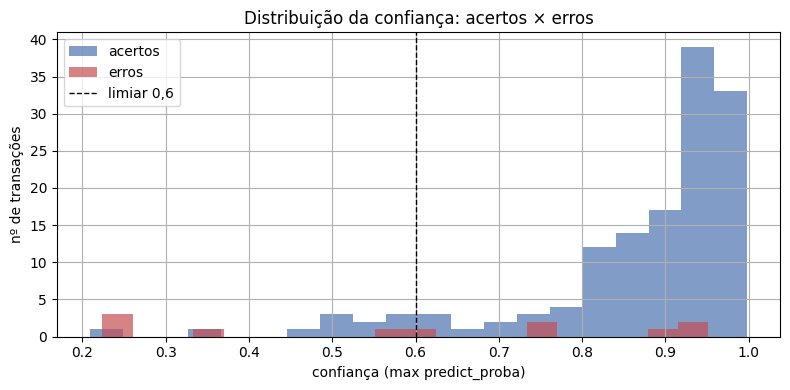

In [12]:
fig, ax = plt.subplots()
ax.hist(pred.loc[pred["acertou"], "confianca"], bins=20, alpha=0.7, label="acertos", color="#4C72B0")
ax.hist(pred.loc[~pred["acertou"], "confianca"], bins=20, alpha=0.7, label="erros", color="#C44E52")
ax.axvline(0.6, color="k", ls="--", lw=1, label="limiar 0,6")
ax.set_title("Distribuição da confiança: acertos × erros")
ax.set_xlabel("confiança (max predict_proba)"); ax.set_ylabel("nº de transações")
ax.legend(); plt.tight_layout(); plt.show()

**Leitura:** os erros vivem na **baixa confiança** e os acertos se empilham perto de 1.
Essa separação é o que torna a confiança acionável: o app categoriza automaticamente o grosso
(alta confiança, accuracy alta) e marca pra revisão a minoria duvidosa — uma UX que **só** o
ML viabiliza, porque regra não tem noção de incerteza.

**Conclusão do notebook:** o ML não venceu por accuracy num benchmark circular. Ele se
justifica por (1) **generalizar** para a bagunça de grafia de um extrato real e (2) entregar
**confiança calibrada** que vira recurso de produto. As métricas por classe e a matriz de
confusão mostram que o erro restante é, em boa parte, o teto honesto do próprio dado
(ambiguidade + label noise).